# Motivation to Derivatives — Part I

This opening lesson introduces the ideas that will be studied in Week 1 and explains why derivatives and optimization matter in machine learning.

## Welcome to Week 1

This week begins with the intuition behind a **derivative**. The first example will use velocity and a speedometer.

The course will then look at familiar mathematical functions:

- constant functions
- linear functions
- quadratics
- polynomials
- exponential functions
- logarithmic functions

You will learn how to find their derivatives and how to work with more complicated functions using:

- the sum rule
- the product rule
- the chain rule
- multiplication by scalars

## Why calculus matters in machine learning

Derivatives are useful for **optimization**: finding the maximum or minimum value of a function.

This is important in machine learning because training a model means finding the model that fits the available data as well as possible. A loss function measures how well the model is doing, and training tries to minimize that loss.

Later lessons will include:

- an example involving temperature
- square loss
- log loss

## Predicting the price of a house

Consider houses with different numbers of bedrooms:

- a one-bedroom house costs **\$150,000**;
- a two-bedroom house costs **\$250,000**;
- the price of a nine-bedroom house is unknown.

The complete example also has prices for houses with 3, 5, 6, 7, 8, and 10 bedrooms. Those prices appear in the lecture's table but are not stated in the transcript, so they are not recreated here.

The goal is to use the known house data to predict the price of the nine-bedroom house.

### Plotting the house data

The horizontal axis represents the number of bedrooms, and the vertical axis represents the house price. Each house is shown as a dot.

The plot below is intentionally schematic because the transcript does not provide every price from the lecture slide. It shows the two stated prices, an illustrative starting line, and a line consistent with the stated prediction of **\$950,000** for nine bedrooms.

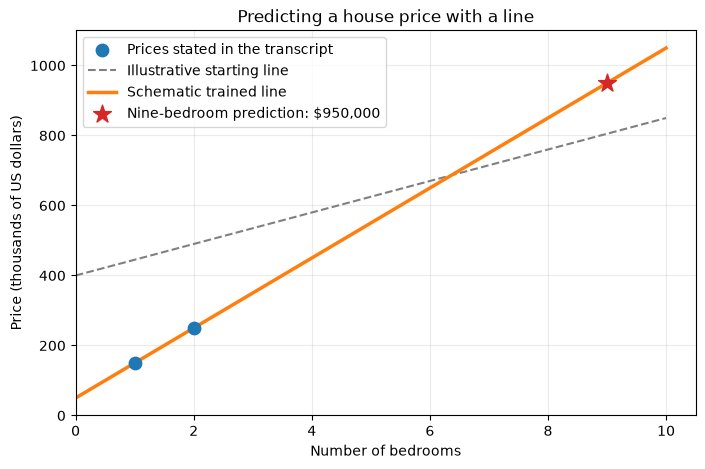

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

known_bedrooms: np.ndarray = np.array([1.0, 2.0])
known_prices: np.ndarray = np.array([150.0, 250.0])
bedroom_range: np.ndarray = np.linspace(0.0, 10.0, 200)
starting_line: np.ndarray = 45.0 * bedroom_range + 400.0
trained_line: np.ndarray = 100.0 * bedroom_range + 50.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    known_bedrooms,
    known_prices,
    color="tab:blue",
    s=80,
    label="Prices stated in the transcript",
    zorder=3,
)
ax.plot(
    bedroom_range,
    starting_line,
    color="gray",
    linestyle="--",
    label="Illustrative starting line",
)
ax.plot(
    bedroom_range,
    trained_line,
    color="tab:orange",
    linewidth=2.5,
    label="Schematic trained line",
)
ax.scatter(
    9,
    950,
    color="tab:red",
    marker="*",
    s=180,
    label="Nine-bedroom prediction: $950,000",
    zorder=4,
)
ax.set(
    xlabel="Number of bedrooms",
    ylabel="Price (thousands of US dollars)",
    title="Predicting a house price with a line",
    xlim=(0, 10.5),
    ylim=(0, 1100),
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### Model training

The machine learning model takes in the known data and begins **model training**.

The lecture compares model training to the engine of a car: it is the important process under the hood of an AI experiment. The model starts with an arbitrary line and adjusts it, looking for a line that goes as close as possible to the known points.

Once training is complete, the model predicts that the nine-bedroom house costs **\$950,000**.

Because the model predicts a numerical value using a line, this is a **linear regression** problem.

## Classifying alien sentiment

Imagine traveling to a distant planet and meeting alien life. You do not need to learn the entire alien language. You only want to predict whether an alien is happy or sad.

The available examples are:

| Sentence | ACK count | BEEP count | Mood |
|---|---:|---:|---|
| `ACK ACK ACK` | 3 | 0 | Happy |
| `BEEP BEEP` | 0 | 2 | Sad |
| `ACK BEEP ACK` | 2 | 1 | Happy |
| `ACK BEEP BEEP BEEP` | 1 | 3 | Sad |

For each sentence, the model records how many times **ACK** and **BEEP** appear. Because the goal is to choose between happy and sad, this is a **classification** problem. More specifically, it is a simple sentiment analysis model.

### Training a classification model

The horizontal axis now represents the number of ACKs, and the vertical axis represents the number of BEEPs.

The model is again a line, but this time the line is used to split the happy points from the sad points. Training moves from a poor line to a better line and finally to a line that separates the four examples.

The exact lines shown in the lecture are not specified in the transcript, so the progression below is schematic.

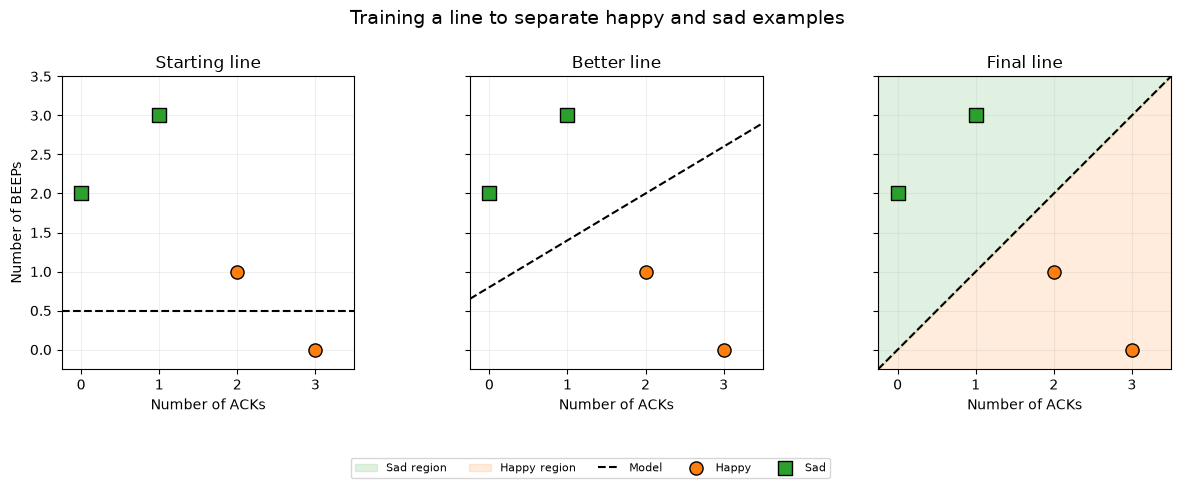

In [2]:
ack_counts: np.ndarray = np.array([3.0, 0.0, 2.0, 1.0])
beep_counts: np.ndarray = np.array([0.0, 2.0, 1.0, 3.0])
moods: np.ndarray = np.array(["Happy", "Sad", "Happy", "Sad"])
axis_values: np.ndarray = np.linspace(-0.25, 3.5, 200)
boundaries: list[tuple[str, float, float]] = [
    ("Starting line", 0.0, 0.5),
    ("Better line", 0.6, 0.8),
    ("Final line", 1.0, 0.0),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for panel, (title, slope, intercept) in enumerate(boundaries):
    ax = axes[panel]
    boundary: np.ndarray = slope * axis_values + intercept

    if panel == 2:
        ax.fill_between(
            axis_values,
            boundary,
            3.5,
            color="tab:green",
            alpha=0.14,
            label="Sad region",
        )
        ax.fill_between(
            axis_values,
            -0.25,
            boundary,
            color="tab:orange",
            alpha=0.14,
            label="Happy region",
        )

    ax.plot(axis_values, boundary, color="black", linestyle="--", label="Model")

    for mood, color, marker in [
        ("Happy", "tab:orange", "o"),
        ("Sad", "tab:green", "s"),
    ]:
        selected: np.ndarray = moods == mood
        ax.scatter(
            ack_counts[selected],
            beep_counts[selected],
            color=color,
            marker=marker,
            edgecolor="black",
            s=90,
            label=mood,
            zorder=3,
        )

    ax.set(
        xlabel="Number of ACKs",
        title=title,
        xlim=(-0.25, 3.5),
        ylim=(-0.25, 3.5),
    )
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Number of BEEPs")
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=5, fontsize=8)
fig.suptitle("Training a line to separate happy and sad examples", fontsize=14)
fig.subplots_adjust(bottom=0.23, top=0.84, wspace=0.18)
plt.show()

The final line splits the plane into two regions:

- the **sad** region is shown in green;
- the **happy** region is shown in orange.

When a new sentence arrives, the model counts its ACKs and BEEPs. The region containing that new point determines the predicted mood.

The model may make mistakes, but based on these examples it should often make a useful prediction.

## Mathematics under the hood

How does a model learn a useful line? Mathematics drives the training process. Important ideas include:

- gradients
- derivatives
- optimization
- loss and cost functions
- gradient descent

This course will explain how these ideas work at the core of model training.

The house and alien examples introduce linear regression and classification, but the same mathematical ideas apply to many other machine learning algorithms, including neural networks.

### Video 1 takeaway

This introductory lesson presents the main motivation for derivatives:

- derivatives help with optimization;
- optimization helps minimize a model's loss;
- minimizing loss is a central part of model training;
- the same training idea appears in regression, classification, and more complex models.

The next lessons begin developing the derivative concepts needed to understand this process.

## Video 2 — Derivatives and velocity

### Average velocity and instantaneous velocity

Imagine traveling 100 kilometers in one hour. Your **average velocity** is 100 kilometers per hour.

That does not mean the car moved at the same velocity for the entire hour. You may have started fast, slowed down, stopped, sped up, or even gone in reverse.

The velocity at one particular moment is called **instantaneous velocity**. This gives the central intuition for a derivative:

> A derivative is the instantaneous rate of change of a function.

In this example, the changing function is distance, and its derivative is velocity.

### A broken speedometer

Suppose you are driving on a straight road. Your speedometer breaks, but an app still records the distance you have traveled.

You drive for one minute and record the distance every five seconds. The full table is shown in the lecture but is not completely included in the transcript, so this notebook uses only the stated values.

Average velocity is the distance traveled divided by the time elapsed:

$$
\text{average velocity}
=
\frac{\text{change in distance}}{\text{change in time}}.
$$

On a distance-versus-time graph:

- $\Delta x$ is the horizontal change in time;
- $\Delta y$ is the vertical change in distance.

Therefore, average velocity is also the slope of the line between two measurements:

$$
\text{average velocity}
=
\text{slope}
=
\frac{\Delta y}{\Delta x}.
$$

### Quiz 1: Is the car moving at constant speed?

No.

From 10 to 15 seconds, the car travels 80 meters during a 5-second interval:

$$
\frac{80\ \text{m}}{5\ \text{s}}=16\ \text{m/s}.
$$

From 15 to 20 seconds, it travels 63 meters during another 5-second interval:

$$
\frac{63\ \text{m}}{5\ \text{s}}=12.6\ \text{m/s}.
$$

The time intervals have the same length, but their average velocities are different. The car is therefore not moving at constant speed.

### Quiz 2: Can we find the exact velocity at 12.5 seconds?

No. The five-second measurements tell us what happened between 10 and 15 seconds as a whole, but not what happened at every instant inside that interval.

The slope

$$
\frac{\Delta y}{\Delta x}
$$

gives the **average** velocity across the interval. At 12.5 seconds, the car may have been moving faster or slower than that average. We can calculate an estimate, but not the exact instantaneous velocity from the given table.

### Average velocity from 10 to 15 seconds

At 10 seconds, the car has traveled 122 meters. At 15 seconds, it has traveled 202 meters.

The horizontal change is the elapsed time:

$$
\Delta x = 15-10 = 5\ \text{s}.
$$

The vertical change is the distance traveled:

$$
\Delta y = 202-122 = 80\ \text{m}.
$$

The slope is therefore

$$
\frac{\Delta y}{\Delta x}
=
\frac{202-122}{15-10}
=
\frac{80}{5}
=
16\ \text{m/s}.
$$

This slope is the average velocity from 10 to 15 seconds and a reasonable estimate of the velocity at 12.5 seconds.

### A better estimate from finer measurements

Now suppose the app records distance every second. Near 12.5 seconds, the transcript gives:

| Time | Distance traveled |
|---:|---:|
| 12 seconds | 155 meters |
| 13 seconds | 170 meters |

For this smaller interval:

$$
\Delta x = 13-12 = 1\ \text{s}
$$

and

$$
\Delta y = 170-155 = 15\ \text{m}.
$$

The new slope is

$$
\frac{\Delta y}{\Delta x}
=
\frac{170-155}{13-12}
=
15\ \text{m/s}.
$$

Because the interval from 12 to 13 seconds is much closer to 12.5 seconds, this is a better estimate than the five-second interval.

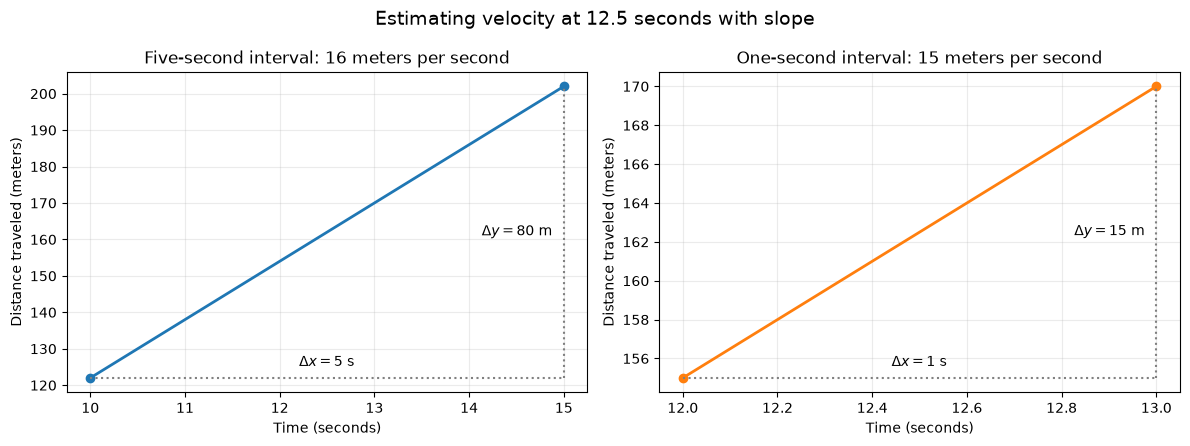

In [3]:
wide_times: np.ndarray = np.array([10.0, 15.0])
wide_distances: np.ndarray = np.array([122.0, 202.0])
narrow_times: np.ndarray = np.array([12.0, 13.0])
narrow_distances: np.ndarray = np.array([155.0, 170.0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(wide_times, wide_distances, color="tab:blue", marker="o", linewidth=2)
axes[0].plot([10, 15], [122, 122], color="gray", linestyle=":")
axes[0].plot([15, 15], [122, 202], color="gray", linestyle=":")
axes[0].annotate(r"$\Delta x=5$ s", (12.5, 122), xytext=(0, 8), textcoords="offset points",
                 ha="center")
axes[0].annotate(r"$\Delta y=80$ m", (15, 162), xytext=(-8, 0), textcoords="offset points",
                 ha="right", va="center")
axes[0].set(
    xlabel="Time (seconds)",
    ylabel="Distance traveled (meters)",
    title="Five-second interval: 16 meters per second",
)
axes[0].grid(alpha=0.25)

axes[1].plot(narrow_times, narrow_distances, color="tab:orange", marker="o", linewidth=2)
axes[1].plot([12, 13], [155, 155], color="gray", linestyle=":")
axes[1].plot([13, 13], [155, 170], color="gray", linestyle=":")
axes[1].annotate(r"$\Delta x=1$ s", (12.5, 155), xytext=(0, 8), textcoords="offset points",
                 ha="center")
axes[1].annotate(r"$\Delta y=15$ m", (13, 162.5), xytext=(-8, 0), textcoords="offset points",
                 ha="right", va="center")
axes[1].set(
    xlabel="Time (seconds)",
    ylabel="Distance traveled (meters)",
    title="One-second interval: 15 meters per second",
)
axes[1].grid(alpha=0.25)

fig.suptitle("Estimating velocity at 12.5 seconds with slope", fontsize=14)
fig.tight_layout()
plt.show()

### From estimates to the derivative

The one-second interval gives a better estimate, but it still does not provide the exact velocity at 12.5 seconds.

To improve the estimate, use measurements from finer and finer time intervals around that instant. As $\Delta x$ becomes smaller, the interval's average velocity becomes a better estimate of the instantaneous velocity.

This is the idea that leads from the slope

$$
\frac{\Delta y}{\Delta x}
$$

to the derivative of distance with respect to time. The next lesson develops that step.